In [1]:
import warnings
warnings.filterwarnings('ignore')

# Data Explotation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #Visualization
import seaborn as sns #Advanced Visualization
%matplotlib inline

# Data modelling libraries
from sklearn.impute import SimpleImputer
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier 

from sklearn.metrics import classification_report, confusion_matrix
import itertools
from sklearn.metrics import f1_score

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder,LabelBinarizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.pipeline import make_pipeline as make_pipeline_imb

In [12]:
#Loading data 
df= pd.read_csv("Fraud Detection Dataset.csv")
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


### EDA

In [4]:
print("Rows, Columns:", df.shape)
print("Columns:", df.columns.tolist())
display(df.info())
display(df.describe(include="all"))

Rows, Columns: (51000, 12)
Columns: ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non

None

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
count,51000,51000.000000,48480.000000,51000,48448.000000,48527,48453,51000.000000,51000.000000,51000.000000,48531,51000.000000
unique,50000,NaN,NaN,5,NaN,4,8,NaN,NaN,NaN,5,NaN
top,T21614,NaN,NaN,Bill Payment,NaN,Desktop,Boston,NaN,NaN,NaN,UPI,NaN
freq,2,NaN,NaN,10340,NaN,15795,6149,NaN,NaN,NaN,11887,NaN
mean,NaN,3005.110176,2996.249784,NaN,11.488400,NaN,NaN,1.995725,60.033902,7.495588,NaN,0.049216
std,NaN,1153.121107,5043.932555,NaN,6.922954,NaN,NaN,1.415150,34.384131,4.020080,NaN,0.216320
min,NaN,1000.000000,5.030000,NaN,0.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,0.000000
25%,NaN,2007.000000,1270.552500,NaN,5.000000,NaN,NaN,1.000000,30.000000,4.000000,NaN,0.000000
50%,NaN,2996.000000,2524.100000,NaN,12.000000,NaN,NaN,2.000000,60.000000,7.000000,NaN,0.000000
75%,NaN,4006.000000,3787.240000,NaN,17.000000,NaN,NaN,3.000000,90.000000,11.000000,NaN,0.000000


In [5]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [27]:
df["col_missing"] = df["Time_of_Transaction"].isna().astype(int)

In [28]:
df.groupby("Fraudulent")["col_missing"].mean()

Fraudulent
0    0.049866
1    0.053386
Name: col_missing, dtype: float64

Fraudulent
0    95.078431
1     4.921569
Name: proportion, dtype: float64

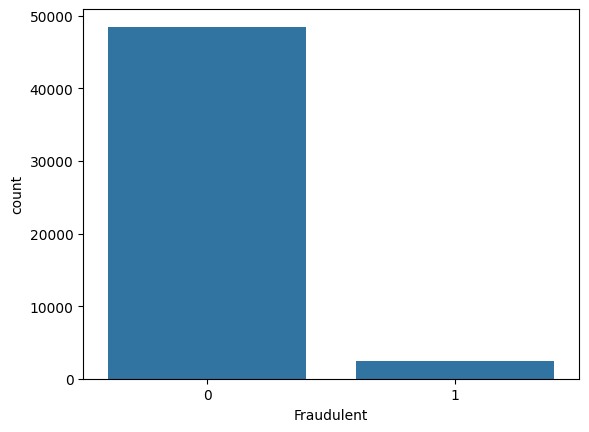

In [30]:
# Check Fraud Distribution
display(df['Fraudulent'].value_counts(normalize=True) * 100)
#display(df.info())

sns.countplot(x='Fraudulent', data=df)
plt.show()

Imbalanced dataset

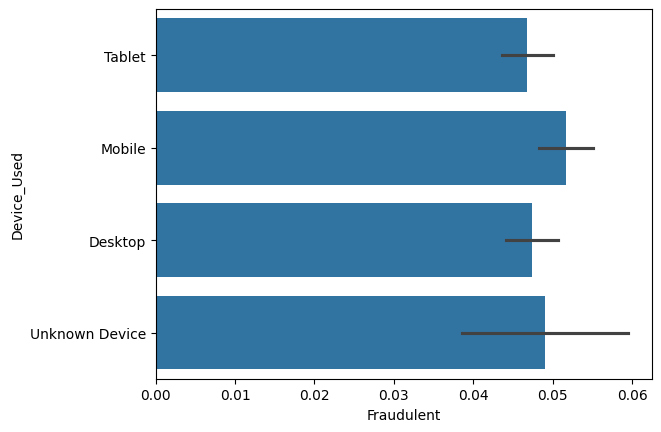

In [40]:
sns.barplot(x='Fraudulent', y='Device_Used', data=df)
plt.show()

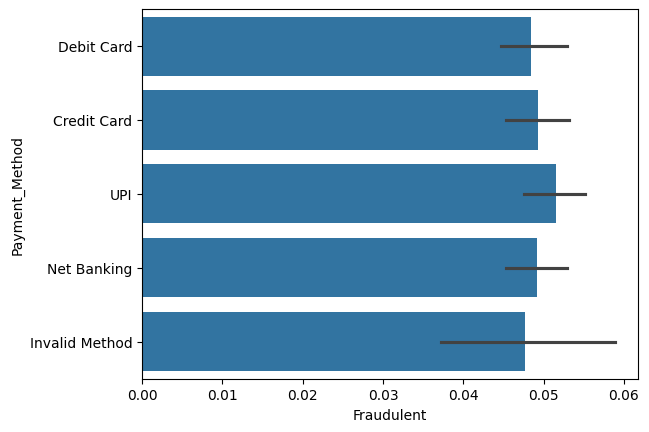

In [8]:
# Fraud by payment type
sns.barplot(x='Fraudulent', y='Payment_Method', data=df)
plt.show()



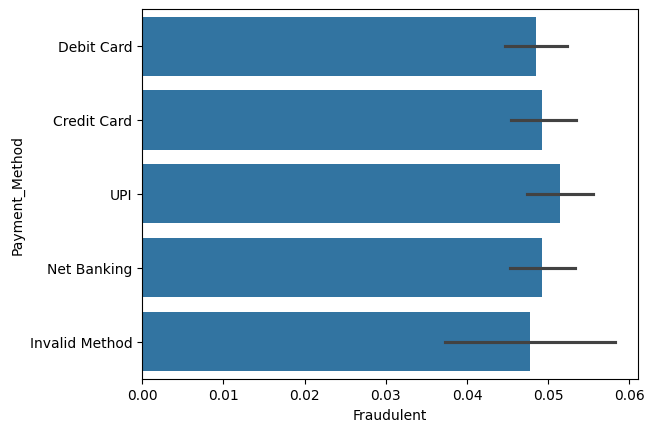

In [39]:
sns.barplot(x='Fraudulent', y='Payment_Method', data=df)
plt.show()

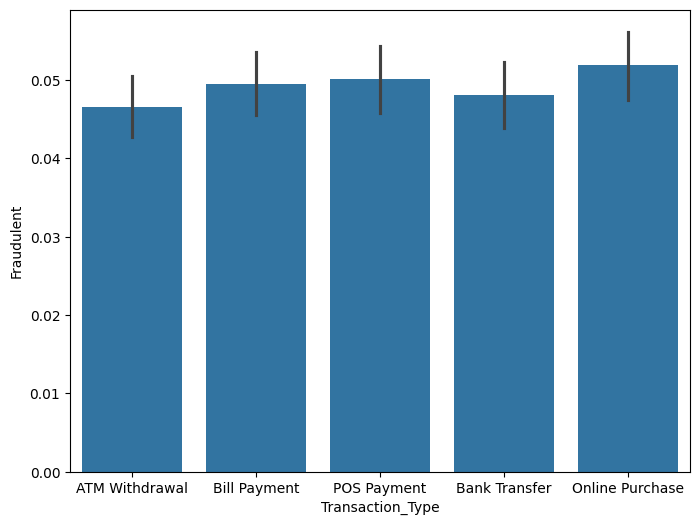

In [38]:
# Fraud by time
plt.figure(figsize=(8,6))
sns.barplot(y='Fraudulent', x='Transaction_Type', data=df)
plt.show()

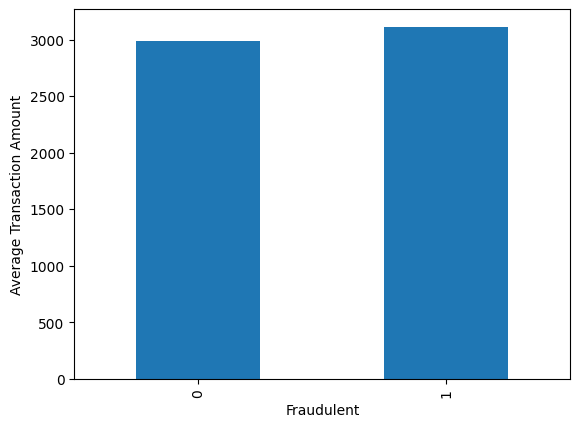

In [31]:
df.groupby('Fraudulent')['Transaction_Amount'].mean().plot(
    kind='bar'
)
plt.ylabel('Average Transaction Amount')
plt.show()

In [31]:
#drop columns Transaction_ID
df = df.drop(columns=['Transaction_ID', 'User_ID'])

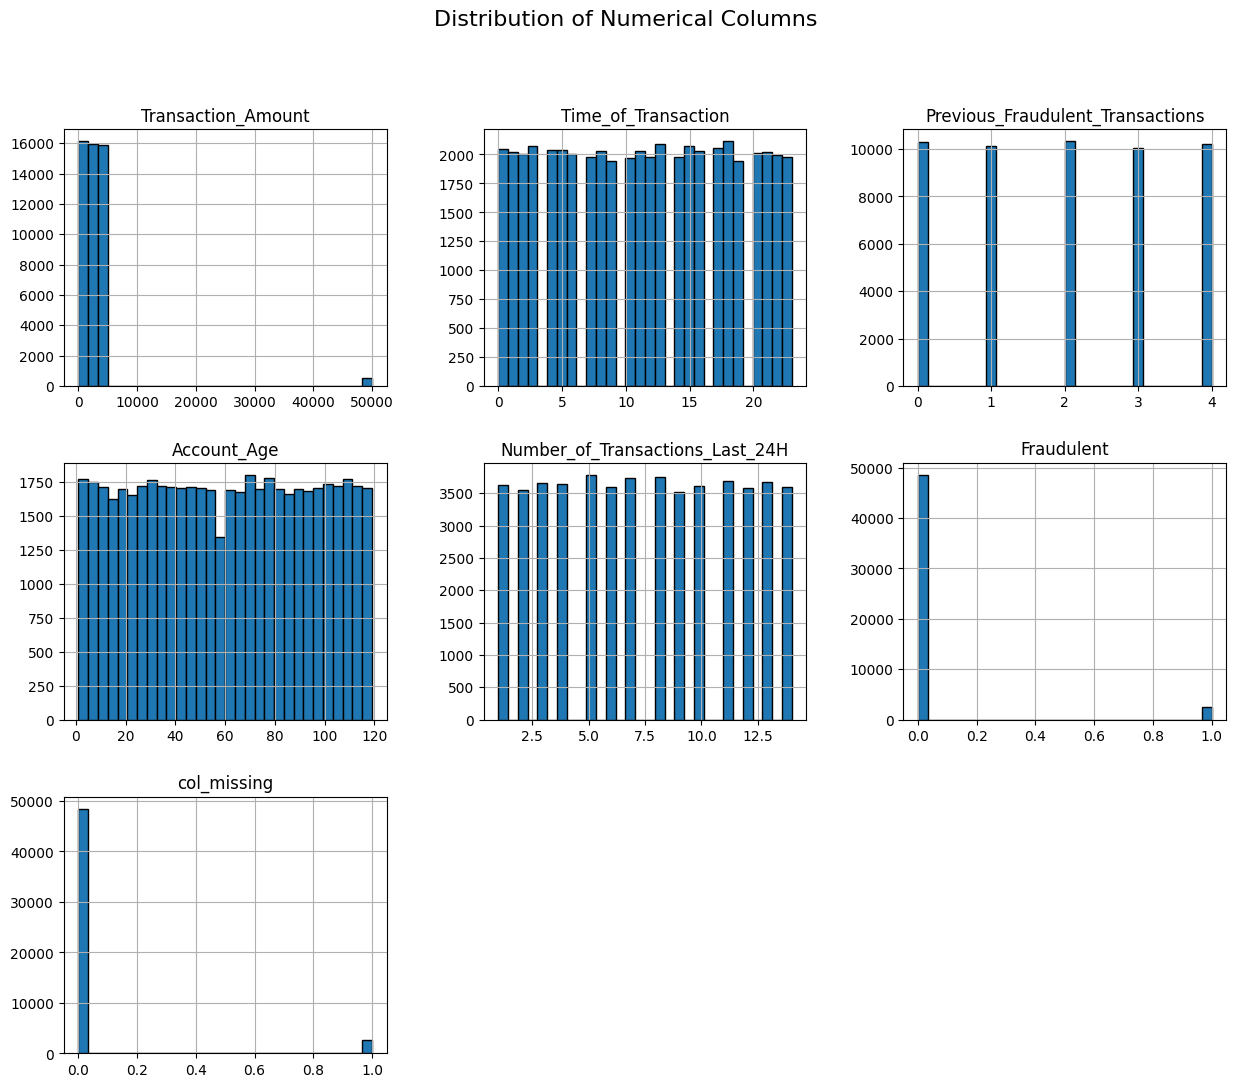

In [33]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
df[num_cols].hist(figsize=(15, 12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Columns", fontsize=16)
plt.show()

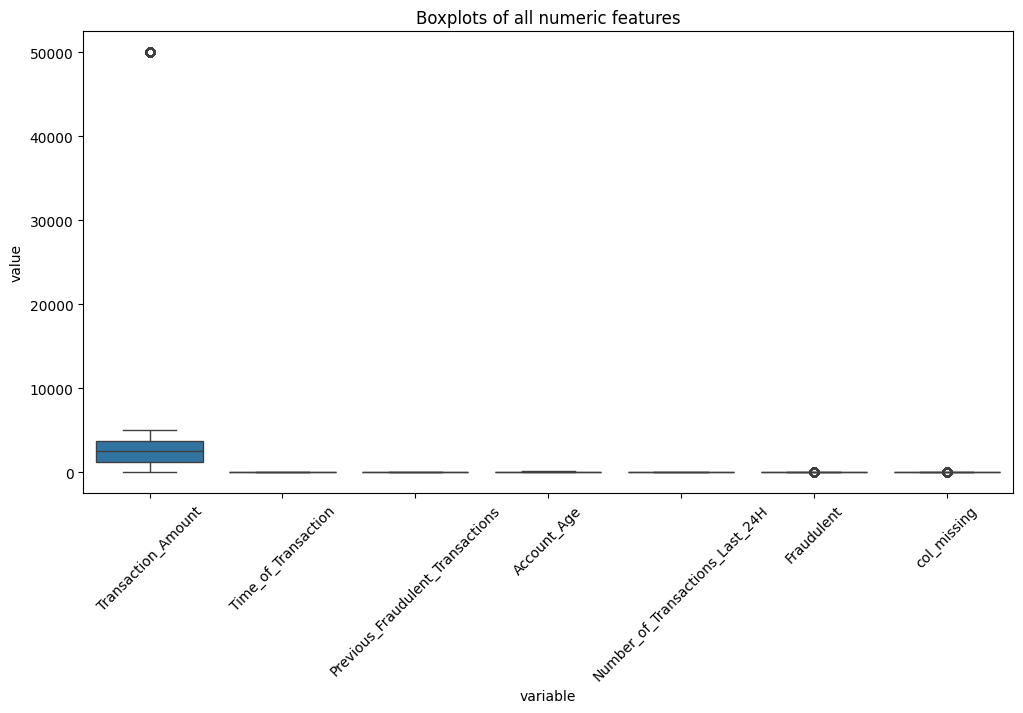

In [34]:
df_melt = df[num_cols].melt()

plt.figure(figsize=(12,6))
sns.boxplot(x="variable", y="value", data=df_melt)
plt.xticks(rotation=45)
plt.title("Boxplots of all numeric features")
plt.show()

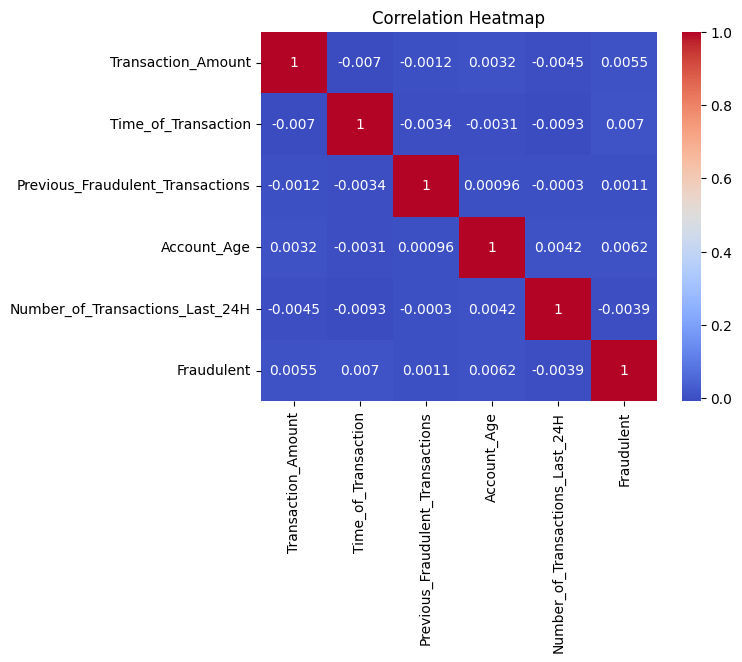

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

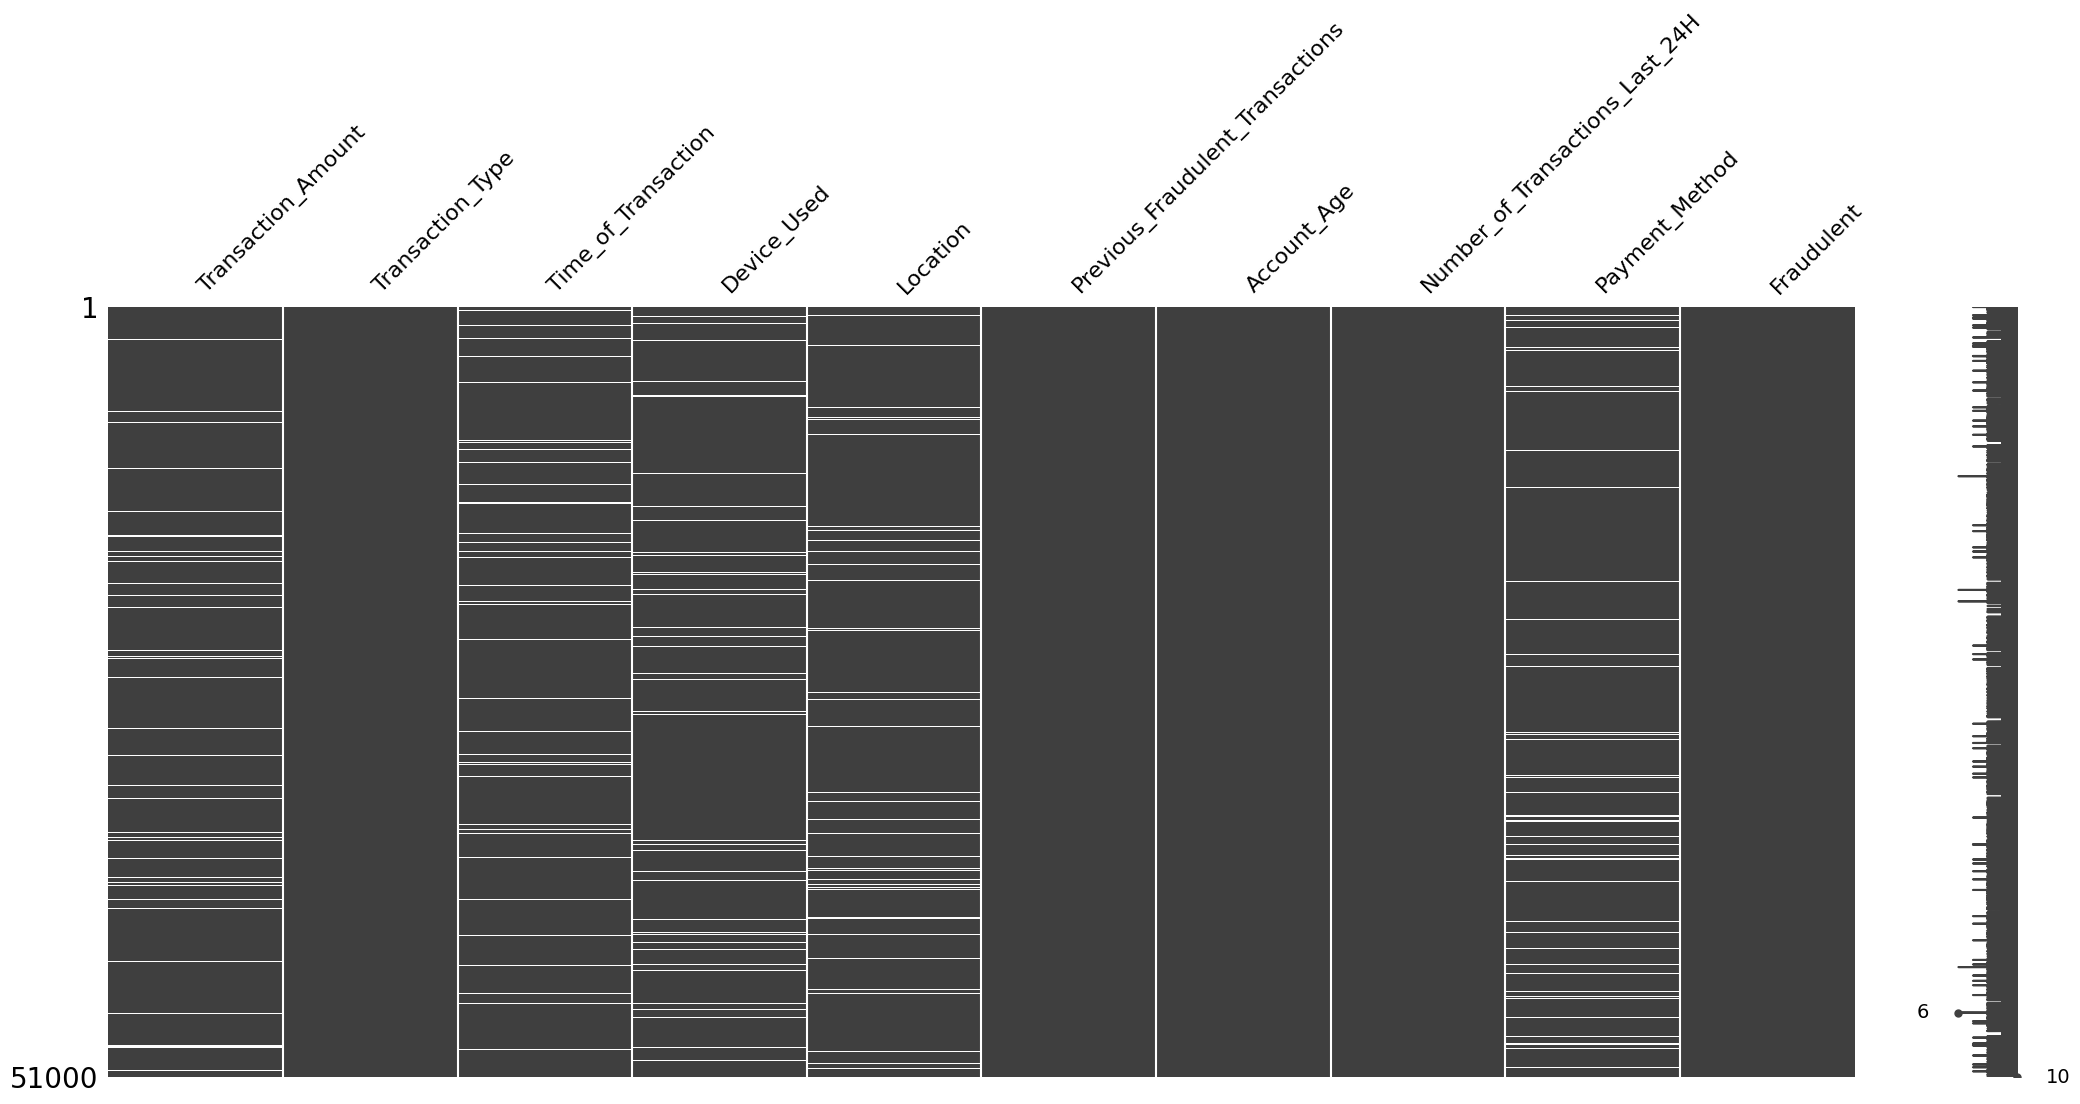

In [9]:
import missingno as msno
msno.matrix(df)
plt.show()

In [35]:
missing_perc = df.isnull().sum() / len(df) * 100
print(missing_perc)

Transaction_Amount                  4.941176
Transaction_Type                    0.000000
Time_of_Transaction                 5.003922
Device_Used                         4.849020
Location                            4.994118
Previous_Fraudulent_Transactions    0.000000
Account_Age                         0.000000
Number_of_Transactions_Last_24H     0.000000
Payment_Method                      4.841176
Fraudulent                          0.000000
col_missing                         0.000000
dtype: float64


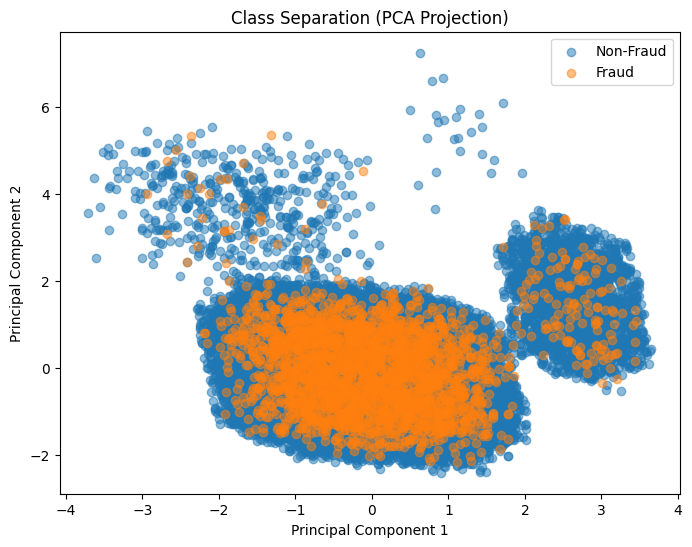

In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Target
y = df["Fraudulent"]

# Features (exclude target)
X = df.drop(columns=["Fraudulent"])

# Keep only numeric columns
X = X.select_dtypes(include=["int64", "float64"])

# Handle missing values if needed
X = X.fillna(X.median())

# Scale features
X_scaled = StandardScaler().fit_transform(X)

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    alpha=0.5,
    label="Non-Fraud"
)

plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    alpha=0.5,
    label="Fraud"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Class Separation (PCA Projection)")
plt.legend()
plt.show()

In [11]:
count_over_5000 = (df['Transaction_Amount'] > 5000).sum()
print(count_over_5000)

508


Deal with the missing row.

In [41]:
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(df['Transaction_Amount'].mean())
df['Time_of_Transaction'] = df['Time_of_Transaction'].fillna(df['Time_of_Transaction'].mean())

#df['Device_Used'] = df['Device_Used'].fillna(df['Device_Used'].mode()[0])
#df['Payment_Method'] = df['Payment_Method'].fillna(df['Payment_Method'].mode()[0])
#df['Location'] = df['Location'].fillna(df['Location'].mode()[0])

df['Device_Used_Missing'] = df['Device_Used'].isna().astype(int)
df['Device_Used'] = df['Device_Used'].fillna('Unknown')

df['Payment_Method_Missing'] = df['Payment_Method'].isna().astype(int)
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')

df['Location_Missing'] = df['Location'].isna().astype(int)
df['Location'] = df['Location'].fillna('Unknown')

In [42]:
missing_perc = df.isnull().sum() / len(df) * 100
print(missing_perc)

Transaction_Amount                  0.0
Transaction_Type                    0.0
Time_of_Transaction                 0.0
Device_Used                         0.0
Location                            0.0
Previous_Fraudulent_Transactions    0.0
Account_Age                         0.0
Number_of_Transactions_Last_24H     0.0
Payment_Method                      0.0
Fraudulent                          0.0
col_missing                         0.0
Device_Used_Missing                 0.0
Payment_Method_Missing              0.0
Location_Missing                    0.0
dtype: float64


### Data Cleaning

In [43]:
df2 = df.copy()

Feature Engineering

In [44]:
display(df2['Transaction_Amount'].mean())

np.float64(2996.249784447194)

In [45]:
# High transaction flag
df2['High_Amount'] = (
    df2['Transaction_Amount'] > df2['Transaction_Amount'].mean()
).astype(int)

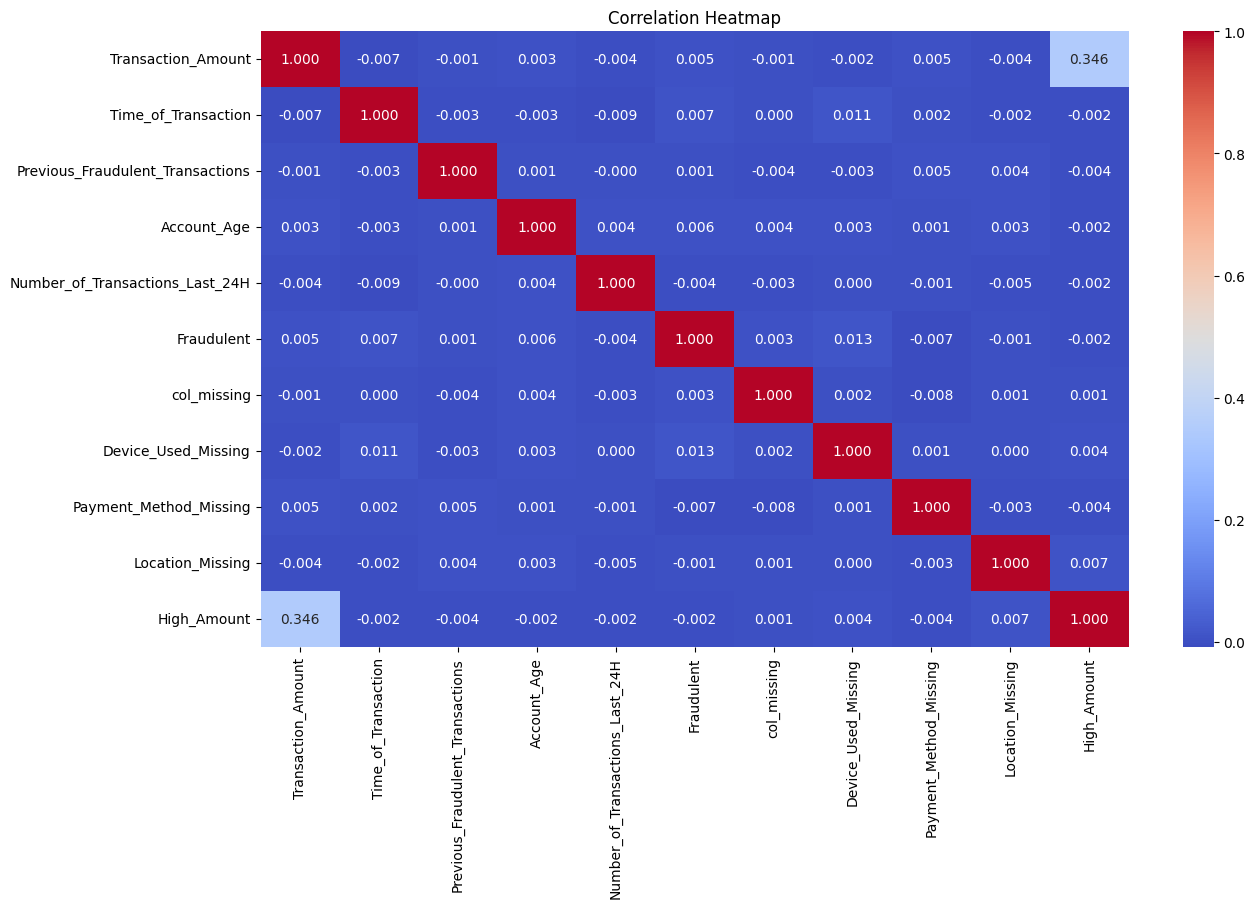

In [46]:
plt.figure(figsize=(14, 8))
sns.heatmap(df2.corr(numeric_only=True), annot=True, fmt=".3f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### Encode Categorical Variables

In [47]:
# One-Hot Encoding
# No ordinal relationship

categorical_cols = [
    'Device_Used',
    'Payment_Method',
    'Location',
    'Transaction_Type'
]

df2 = pd.get_dummies(
    df2,
    columns=categorical_cols,
    drop_first=True
)

In [48]:
df2.head()

,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,col_missing,Device_Used_Missing,Payment_Method_Missing,Location_Missing,...,Location_Los Angeles,Location_Miami,Location_New York,Location_San Francisco,Location_Seattle,Location_Unknown,Transaction_Type_Bank Transfer,Transaction_Type_Bill Payment,Transaction_Type_Online Purchase,Transaction_Type_POS Payment
0,1292.76,16.0000,0,119,13,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False
1,1554.58,13.0000,4,79,3,0,0,0,0,0,...,False,False,True,False,False,False,False,False,False,False
2,2395.02,11.4884,3,115,9,0,1,0,1,1,...,False,False,False,False,False,True,False,False,False,False
3,100.10,15.0000,4,3,4,0,0,0,0,0,...,False,False,False,False,False,False,False,True,False,False
4,1490.50,19.0000,2,57,7,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,True


Split Features and Target

In [49]:
X = df2.drop(['Fraudulent'], axis=1)
y = df2['Fraudulent']

Train-Test Split

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Keeps fraud ratio balanced in train/test sets.
)

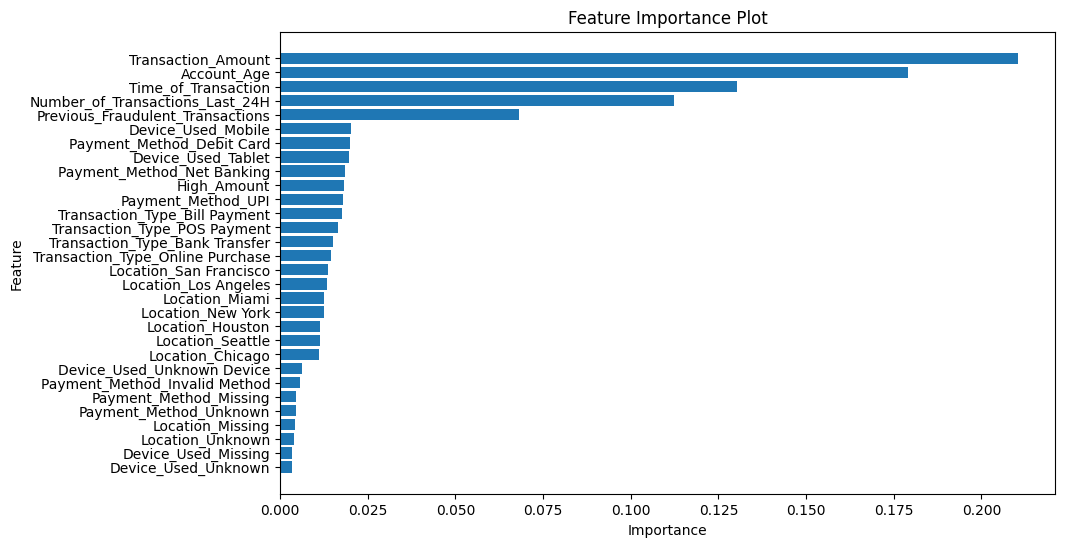

In [57]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importance = rf.feature_importances_

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort values
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance Plot")

plt.show()

In [58]:
# Engineered columns here
display(df2[["Transaction_Amount","Account_Age","Time_of_Transaction",'Previous_Fraudulent_Transactions', 'Number_of_Transactions_Last_24H']].head())

,Transaction_Amount,Account_Age,Time_of_Transaction,Previous_Fraudulent_Transactions,Number_of_Transactions_Last_24H
0,1292.76,119,16.0000,0,13
1,1554.58,79,13.0000,4,3
2,2395.02,115,11.4884,3,9
3,100.10,3,15.0000,4,4
4,1490.50,57,19.0000,2,7


Class Imbalance is high. Use Smote to handle imbalance

In [51]:
print(y_train.value_counts())

Fraudulent
0    38792
1     2008
Name: count, dtype: int64


In [52]:
weight_0 = 1
weight_1 = 38792 / 2009  # = 19

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [54]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
from sklearn.svm import SVC

model = SVC(class_weight='balanced')
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [56]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(class_weight='balanced')
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Scale Numerical Features

In [58]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Define scalers
#scaler_standard = StandardScaler()
scaler_robust = RobustScaler()
scaler_minmax = MinMaxScaler()

# Define which features use which scaler (based on EDA)
#standard_cols = ['CreditScore', 'Age']          # approx normal
robust_cols   = ['Transaction_Amount', 'Time_of_Transaction', 'Account_Age']  # skewed / outliers
minmax_cols   = ['Previous_Fraudulent_Transactions', 'Number_of_Transactions_Last_24H']     # bounded features

# Preprocessor: different scalers for different columns
preprocessor = ColumnTransformer(
    transformers=[
        #('standard', StandardScaler(), standard_cols),
        ('robust', RobustScaler(), robust_cols),
        ('minmax', MinMaxScaler(), minmax_cols)
    ]
)

Train Multiple Models

In [59]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),    
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': make_pipeline_imb(SMOTE(random_state=42), KNeighborsClassifier()),
    'Support Vector Machine': make_pipeline_imb(SMOTE(random_state=42), SVC(probability=True, random_state=42)),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train), random_state=42),
    'Gradient Boosting': make_pipeline_imb(SMOTE(random_state=42), GradientBoostingClassifier(random_state=42))
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # If model already has SMOTE pipeline
    if "SMOTE" in str(model):
        clf = make_pipeline_imb(preprocessor, model)
    else:
        clf = make_pipeline(preprocessor, model)

    # Fit model
    clf.fit(X_train, y_train)

    # Store trained pipeline
    trained_models[name] = clf

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training K-Nearest Neighbors...
Training Support Vector Machine...
Training XGBoost...
Training Gradient Boosting...


Evaluate the Models

In [60]:
# Dictionary to store evaluation results
results = {}

for name, model in trained_models.items():
    print(f"\nEvaluating {name}...")
    
    # Predictions on training and testing data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Training scores
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    
    # Testing scores
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # Store results
    results[name] = {
        'Train Accuracy': train_accuracy,
        'Train Precision': train_precision,
        'Train Recall': train_recall,
        'Train F1': train_f1,
        'Test Accuracy': test_accuracy,
        'Test Precision': test_precision,
        'Test Recall': test_recall,
        'Test F1': test_f1
    }

# Convert to DataFrame for better visualization
results_df = pd.DataFrame(results).T
display(results_df)


Evaluating Logistic Regression...

Evaluating Decision Tree...

Evaluating Random Forest...

Evaluating K-Nearest Neighbors...

Evaluating Support Vector Machine...

Evaluating XGBoost...

Evaluating Gradient Boosting...


,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
Logistic Regression,0.526495,0.051738,0.497510,0.093728,0.520588,0.048374,0.468127,0.087687
Decision Tree,0.999975,0.999502,1.000000,0.999751,0.911569,0.079832,0.075697,0.077710
Random Forest,0.999853,0.999501,0.997510,0.998504,0.951863,0.866667,0.025896,0.050290
K-Nearest Neighbors,0.857132,0.256220,1.000000,0.407923,0.757843,0.048209,0.209163,0.078358
Support Vector Machine,0.465049,0.054451,0.603088,0.099885,0.455686,0.048462,0.539841,0.088940
XGBoost,0.845025,0.233872,0.944223,0.374889,0.781667,0.052413,0.201195,0.083162
Gradient Boosting,0.950784,0.000000,0.000000,0.000000,0.950784,0.000000,0.000000,0.000000


Best performing so far are:
- LR
- SVM

TUNE LR & SVM

In [61]:
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}
0.09233499802464347


In [65]:
best_lr = grid_lr.best_estimator_

y_pred = best_lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.36      0.52      9698
           1       0.05      0.63      0.09       502

    accuracy                           0.37     10200
   macro avg       0.50      0.49      0.30     10200
weighted avg       0.90      0.37      0.50     10200



In [31]:
error_df = X_test.copy()

error_df["Actual"] = y_test.values
error_df["Predicted"] = y_test_pred

error_df["Error_Type"] = "Correct"

error_df.loc[
    (error_df["Actual"] == 1) &
    (error_df["Predicted"] == 0),
    "Error_Type"
] = "False Negative"

error_df.loc[
    (error_df["Actual"] == 0) &
    (error_df["Predicted"] == 1),
    "Error_Type"
] = "False Positive"

In [32]:
error_df["Error_Type"].value_counts()

Error_Type
Correct           9698
False Negative     502
Name: count, dtype: int64


Support Vector Machine Error Analysis

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.45      0.61      9698
           1       0.05      0.54      0.09       502

    accuracy                           0.46     10200
   macro avg       0.50      0.50      0.35     10200
weighted avg       0.91      0.46      0.59     10200



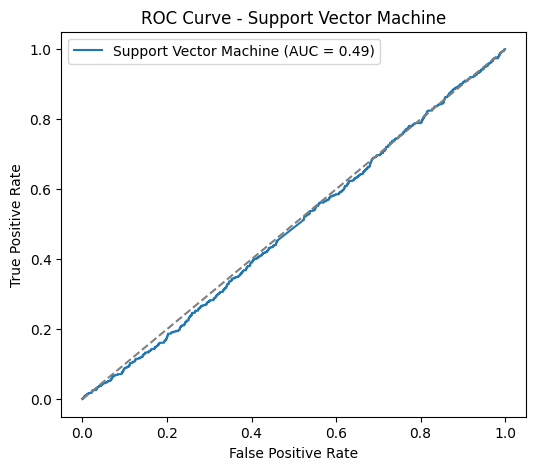


Gradient Boosting Error Analysis

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9698
           1       0.00      0.00      0.00       502

    accuracy                           0.95     10200
   macro avg       0.48      0.50      0.49     10200
weighted avg       0.90      0.95      0.93     10200



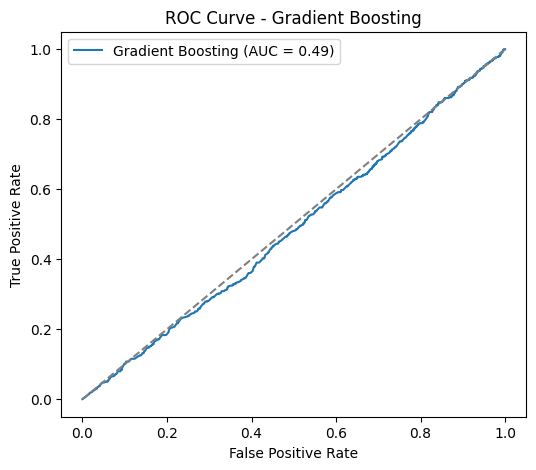

In [41]:
from sklearn.metrics import classification_report, roc_curve, auc

# Selected models
selected_models = {
    "Support Vector Machine": trained_models['Support Vector Machine'],
    "Gradient Boosting": trained_models['Gradient Boosting']
}

for name, model in selected_models.items():
    print(f"\n{name} Error Analysis")
    print("="*40)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
  

    # 1. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # 2. ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend()
    plt.show()



Support Vector Machine Detailed Error Analysis


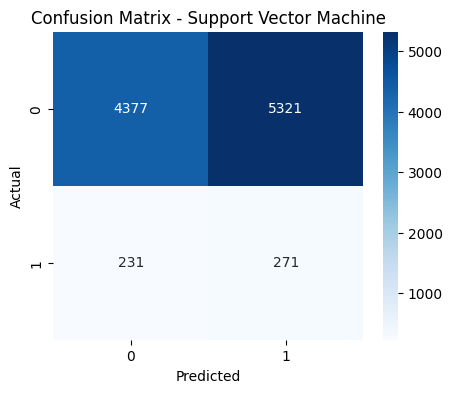

Number of misclassified samples: 5552
Sample of misclassified indices: [1515, 25641, 23160, 38334, 21518, 45474, 39487, 50819, 28226, 47404]

Threshold = 0.3
[[   5 9693]
 [   0  502]]

Threshold = 0.5
[[4627 5071]
 [ 245  257]]

Threshold = 0.7
[[9698    0]
 [ 502    0]]

Gradient Boosting Detailed Error Analysis


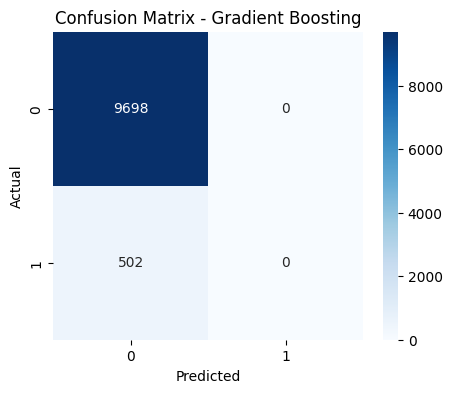

Number of misclassified samples: 502
Sample of misclassified indices: [50273, 15034, 14086, 27086, 49401, 8810, 15322, 12302, 47110, 40414]

Threshold = 0.3
[[5221 4477]
 [ 279  223]]

Threshold = 0.5
[[9698    0]
 [ 502    0]]

Threshold = 0.7
[[9698    0]
 [ 502    0]]


In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

for name, model in selected_models.items():
    print(f"\n{name} Detailed Error Analysis")
    print("="*50)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # 2. Misclassified Samples
    misclassified_idx = X_test.index[y_test != y_pred]
    print(f"Number of misclassified samples: {len(misclassified_idx)}")
    if len(misclassified_idx) > 0:
        print("Sample of misclassified indices:", misclassified_idx[:10].tolist())

    # 3. Threshold Analysis
    thresholds = [0.3, 0.5, 0.7]  # Example thresholds
    for thresh in thresholds:
        y_thresh_pred = (y_pred_proba >= thresh).astype(int)
        cm_thresh = confusion_matrix(y_test, y_thresh_pred)
        print(f"\nThreshold = {thresh}")
        print(cm_thresh)